# Desenvolvimento de Modelo para Identificação de Linguagens de Sinais Brasileira

## Importações e Preparação de Variáveis de Caminho

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from os.path import basename

DATASET_PATH = "/kaggle/input/datasets/allanpardinho/libras-cnn"

2026-03-14 19:08:44.605679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773515324.820559      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773515324.885772      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773515325.407525      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773515325.407590      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773515325.407594      24 computation_placer.cc:177] computation placer alr

## Preparação de Dataset de Imagens e Variáveis de Trainamento

#### De forma simplificada, o TensorFlow já possui uma função embutida que carrega imagens diretamente de pastas organizadas por categoria e as transforma automaticamente em um dataset pronto para treinar modelos de deep learning.

In [2]:
# Poderemos alterar esses valores a fim de aprimorar a rede
IMG_SIZE = (128, 128) # Redimensiona para economizar memória e manter detalhes
BATCH_SIZE = 32        
EPOCHS = 10             

# Carregamos os Datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/allanpardinho/libras-cnn/train",
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/allanpardinho/libras-cnn/test",
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 34714 files belonging to 21 classes.


I0000 00:00:1773515376.390734      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773515376.398023      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 11548 files belonging to 21 classes.


## Preparando a Rede 1

#### Iniciemos com um modelo simples e de rápido treinamento a fim de verificar a evolução da Rede.

In [3]:
model_1 = models.Sequential([

    # input_shape: formato das imagens de entrada
    #   - (128, 128): altura e largura da imagem em pixels
    #   - 3: número de canais (RGB = 3 canais de cor)
    layers.Input(shape=(128, 128, 3)), 
    
    # Rescaling: redimensiona os valores dos pixels
    # 1./255: converte pixels de 0-255 para 0-1 (normalização)
    layers.Rescaling(1./255),
    
    # Conv2D: camada convolucional 2D
    #   - 32: número de neurônios nesta camada
    #   - (3,3): janela 3x3 pixels
    # Função: detecta características simples (bordas, cantos, linhas)
    layers.Conv2D(32, (3, 3), activation='relu'),
    # MaxPooling2D: redução de dimensionalidade
    #   - (2,2): janela 2x2 que pega o valor máximo
    #   - Reduz imagem para metade do tamanho (64x64)
    #   - Mantém as características importantes com menos pixels
    layers.MaxPooling2D((2, 2)),
    
    # Flatten: transforma matriz 2D em vetor 1D
    layers.Flatten(),
    
    # Dropout: desativa aleatoriamente 50% dos neurônios durante treino
    #   - 0.5: probabilidade de desativar cada neurônio
    #   - Evita overfitting (decorar) - força aprendizado redundante
    # Camada intermediária para "processar" as características extraídas
    layers.Dropout(0.5),
    
    # Dense: camada final de classificação (letra A-Z)
    #   - activation='softmax': produz probabilidades que somam 1
    layers.Dense(21, activation='softmax')
])

model_1.compile(
    optimizer='adam',           # Algoritmo de otimização (Adam)
    loss='categorical_crossentropy',  # Função de perda para classificação multi-classe
    metrics=['accuracy']        # Métrica para monitorar (acurácia)
)

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 21)             │     2,667,189 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,668,085 (10.18 MB)

 Trainable params: 2,668,085 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history_1 = model_1.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/10


I0000 00:00:1773515388.844694      73 service.cc:152] XLA service 0x7f8ddc008030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773515388.844755      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773515388.844766      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773515389.119568      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


   8/1085 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.0368 - loss: 12.0381

I0000 00:00:1773515391.912779      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1085/1085 ━━━━━━━━━━━━━━━━━━━━ 52s 44ms/step - accuracy: 0.5560 - loss: 2.5001 - val_accuracy: 0.7515 - val_loss: 0.9426
Epoch 2/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.8939 - loss: 0.4227 - val_accuracy: 0.7899 - val_loss: 0.7941
Epoch 3/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9425 - loss: 0.2284 - val_accuracy: 0.8043 - val_loss: 0.7223
Epoch 4/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9671 - loss: 0.1295 - val_accuracy: 0.8064 - val_loss: 0.7596
Epoch 5/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9810 - loss: 0.0797 - val_accuracy: 0.8146 - val_loss: 0.7332
Epoch 6/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9856 - loss: 0.0572 - val_accuracy: 0.8328 - val_loss: 0.7101
Epoch 7/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9913 - loss: 0.0382 - val_accuracy: 0.8194 - val_loss: 0.7755
Epoch 8/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9935 - loss: 0.03

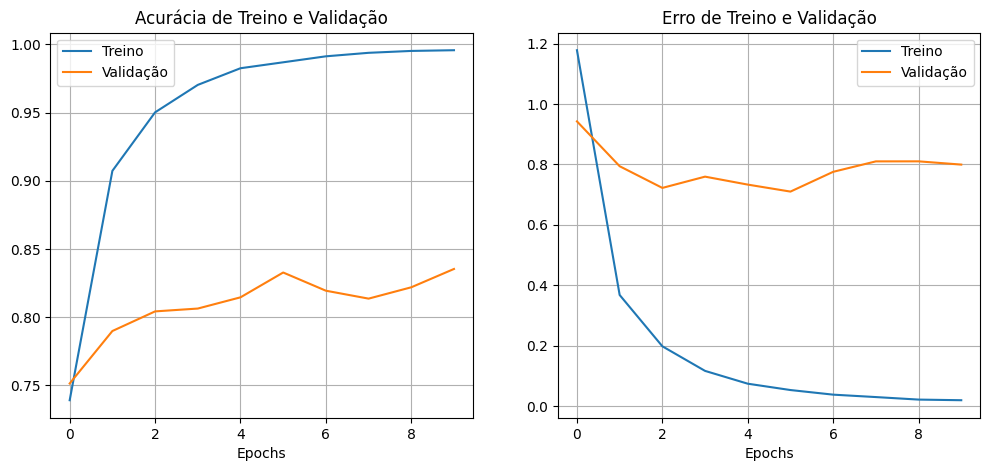

In [5]:
def show_history(history: dict) -> None:
    # Pegamos os parâmetros de evolução da rede
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))
    
    # Preparamos ambos gráficos
    # Gráfico de Acurácia
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Treino')
    plt.plot(epochs_range, val_acc, label='Validação')
    plt.title('Acurácia de Treino e Validação')
    plt.legend()
    plt.grid(True)
    plt.xlabel("Epochs")
    # Gráfico de Erro
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Treino')
    plt.plot(epochs_range, val_loss, label='Validação')
    plt.title('Erro de Treino e Validação')
    plt.grid(True)
    plt.xlabel("Epochs")
    plt.legend()
    
    plt.show()

show_history(history_1)

#### Observe pelo gráfico como, apesar da acurácia e do erro serem bons no contexto de treinamento, os resultados no processo de validação são péssimos. 

#### A rede está sobre **Overfitting**, pois está decorando os dados de treinamento e fracassando ao receber dados novos.

#### Há algumas técnicas para previnir isso, mas, por enquanto, tentemos apenas aumentar a complexidade da rede.

## Preparando Rede 2

#### Aumentemos as camadas da rede a fim de permitir mais capacidade de aprendizado.

In [6]:
model_2 = models.Sequential([

    # input_shape: formato das imagens de entrada
    #   - (128, 128): altura e largura da imagem em pixels
    #   - 3: número de canais (RGB = 3 canais de cor)
    layers.Input(shape=(128, 128, 3)), 
    
    # Rescaling: redimensiona os valores dos pixels
    # 1./255: converte pixels de 0-255 para 0-1 (normalização)
    layers.Rescaling(1./255),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten: transforma matriz 2D em vetor 1D
    #   - Converte (16,16,128) para um vetor de 32768 elementos
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(21, activation='softmax')
])

model_2.compile(
    optimizer='adam',           # Algoritmo de otimização (Adam)
    loss='categorical_crossentropy',  # Função de perda para classificação multi-classe
    metrics=['accuracy']        # Métrica para monitorar (acurácia)
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,684,117 (6.42 MB)

 Trainable params: 1,684,117 (6.42 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_2 = model_2.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/10


2026-03-14 19:13:21.126831: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 19:13:21.280390: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1082/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4330 - loss: 1.8423

2026-03-14 19:13:49.346328: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 19:13:49.499606: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1085/1085 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.4339 - loss: 1.8395 - val_accuracy: 0.8722 - val_loss: 0.4071
Epoch 2/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.8800 - loss: 0.3675 - val_accuracy: 0.8968 - val_loss: 0.3341
Epoch 3/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.9234 - loss: 0.2202 - val_accuracy: 0.9209 - val_loss: 0.2915
Epoch 4/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.9430 - loss: 0.1607 - val_accuracy: 0.9268 - val_loss: 0.2968
Epoch 5/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.9521 - loss: 0.1379 - val_accuracy: 0.9331 - val_loss: 0.2905
Epoch 6/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.9602 - loss: 0.1147 - val_accuracy: 0.9332 - val_loss: 0.3267
Epoch 7/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.9672 - loss: 0.0967 - val_accuracy: 0.9241 - val_loss: 0.3676
Epoch 8/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.9720 - loss: 0.08

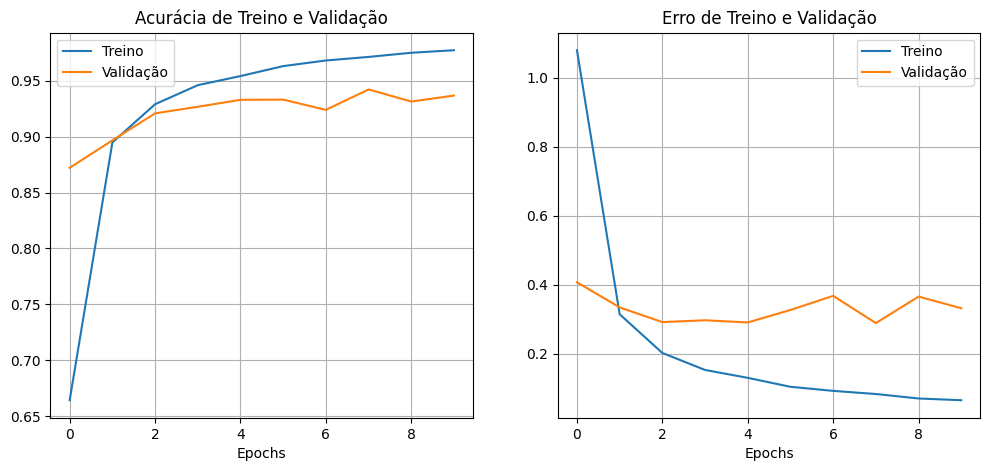

In [8]:
show_history(history_2)

## Preparando Rede 3


In [9]:
model_final = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),
    
    # Bloco 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloco 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloco 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Em vez de Flatten, usamos GlobalAveragePooling para economizar memória (foco em microcontroladores)
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    
    layers.Dense(21, activation='softmax') 
])

model_final.compile(
    optimizer='adam',           # Algoritmo de otimização (Adam)
    loss='categorical_crossentropy',  # Função de perda para classificação multi-classe
    metrics=['accuracy']        # Métrica para monitorar (acurácia)
)

model_final.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,469 (439.33 KB)

 Trainable params: 112,469 (439.33 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_final = model_final.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.0439 - loss: 3.0458 - val_accuracy: 0.0476 - val_loss: 3.0441
Epoch 2/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.0790 - loss: 2.9088 - val_accuracy: 0.3095 - val_loss: 2.0747
Epoch 3/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.3317 - loss: 1.8303 - val_accuracy: 0.5658 - val_loss: 1.1336
Epoch 4/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.5448 - loss: 1.2015 - val_accuracy: 0.6703 - val_loss: 0.9008
Epoch 5/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.6407 - loss: 0.9406 - val_accuracy: 0.7979 - val_loss: 0.6639
Epoch 6/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.7072 - loss: 0.7759 - val_accuracy: 0.8369 - val_loss: 0.5219
Epoch 7/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.7602 - loss: 0.6373 - val_accuracy: 0.8471 - val_loss: 0.4566
Epoch 8/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.7853 -

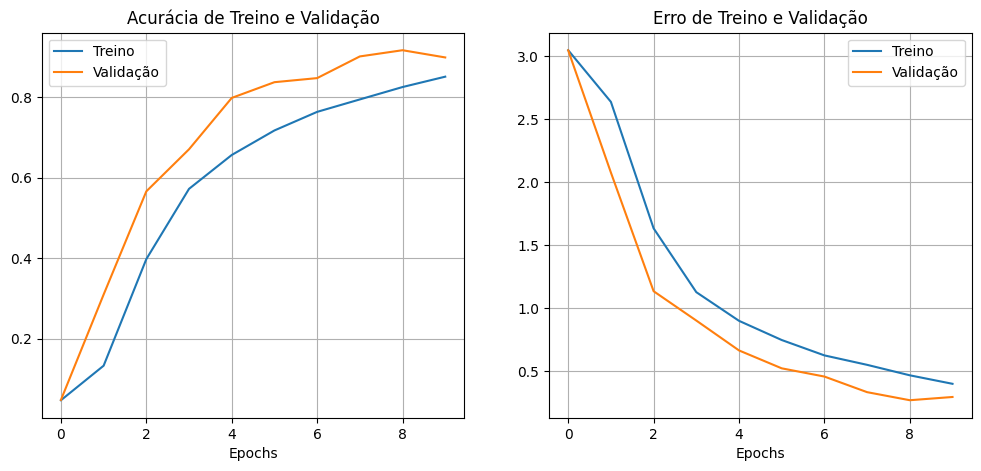

In [11]:
show_history(history_final)

# Comprovação

#### A fim de realizarmos um teste interessante, fornecerei uma imagem de minha autoria e verificarei as predições.

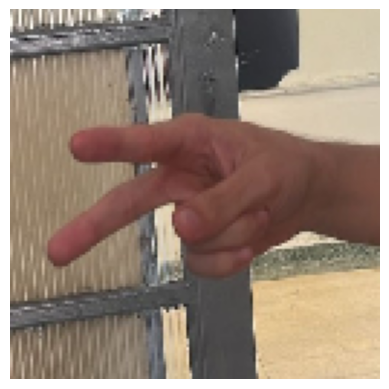

Modelo 1 prediz D com 98.48306274414062
Modelo 2 prediz P com 99.0983657836914
Modelo 3 prediz P com 72.1156997680664


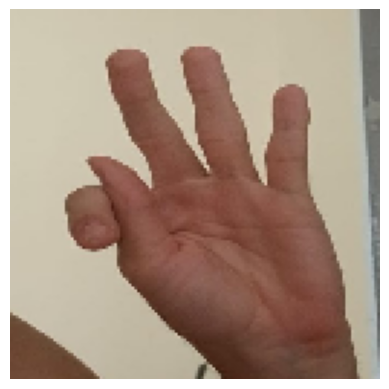

Modelo 1 prediz S com 99.98503875732422
Modelo 2 prediz C com 98.99427795410156
Modelo 3 prediz O com 99.21166229248047


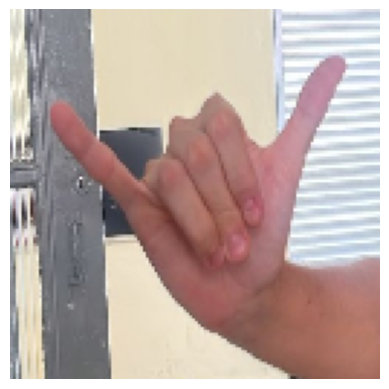

Modelo 1 prediz S com 95.7992172241211
Modelo 2 prediz Y com 99.5189437866211
Modelo 3 prediz C com 99.35709381103516


In [12]:
def validate_through_practical_testing(model: models.Sequential, img_path: str, show_img: bool = True) -> tuple[list[str, float], list[float]]:
    """
    @brief A partir de uma imagem dada, vamos verificar as predições do modelo fornecido
    @param model Modelo de Rede CNN fornecido
    @param img_path Caminho da imagem
    @param show_img Se a imagem será apresentada
    @return Tupla contendo uma lista da classe predita e seu nível de confiança e uma lista de todas as predi
    """

    # Carregamos a imagem de um jeito bizurado pelo TensorFlow
    img = tf.keras.utils.load_img(
        img_path,
        target_size=(128, 128)
    )
    
    # Devemos criar um tensor para fornecer a rede, dado que ela não foi preparada para receber uma 
    # imagem por vez e realizar as predições
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    
    predictions = model.predict(img_array, verbose=0)[0]
    predicted_class = train_ds.class_names[np.argmax(predictions)]
    trust_level = 100 * np.max(predictions)

    if show_img:
        plt.imshow(img)
        plt.axis('off')
        plt.show()

    return [predicted_class, trust_level], predictions

models_and_ids = [
    [model_1, "1"],
    [model_2, "2"],
    [model_final, "3"]
]

path_imgs = [
    # Não ironicamente, por algum motivo, algumas letras dadas pelo usuário estão com diferentes do padrão
    # Se é que existe um padrão, pois ao tentar pesquisar no google, diferentes fontes apresentaram diferentes resultados.
    # Sem falar que esse Dataset é pobre de variedades
    #"N", 
    "P", 
    "T", 
    "Y"
]
complete_img_path = lambda letter: f"/kaggle/input/datasets/mathdeyvi/apenasminhamao/{letter}_como_minha_mao.jpeg"

# Apenas porque eu gosto de escrever código compactado assim
# results = {
#     letter: {
#         id_model: validate_through_practical_testing(
#             model,
#             complete_img_path(letter),
#             id_model == "1"
#         ) for model, id_model in models_ids
#     } for letter in path_imgs
# }

results = {}

for letter in path_imgs:
    results[letter] = {}

    for model, id_model in models_and_ids:
        results[letter][id_model] = validate_through_practical_testing(
            model,
            complete_img_path(letter),
            id_model == "1"
        )

        print(
            f"Modelo {id_model} prediz {results[letter][id_model][0][0]} com {results[letter][id_model][0][1]}" 
        )

#### Como uma forma de debuggarmos como a rede está interpretando essa imagem dada, vamos plotar um gráfico do resultado direto da rede.

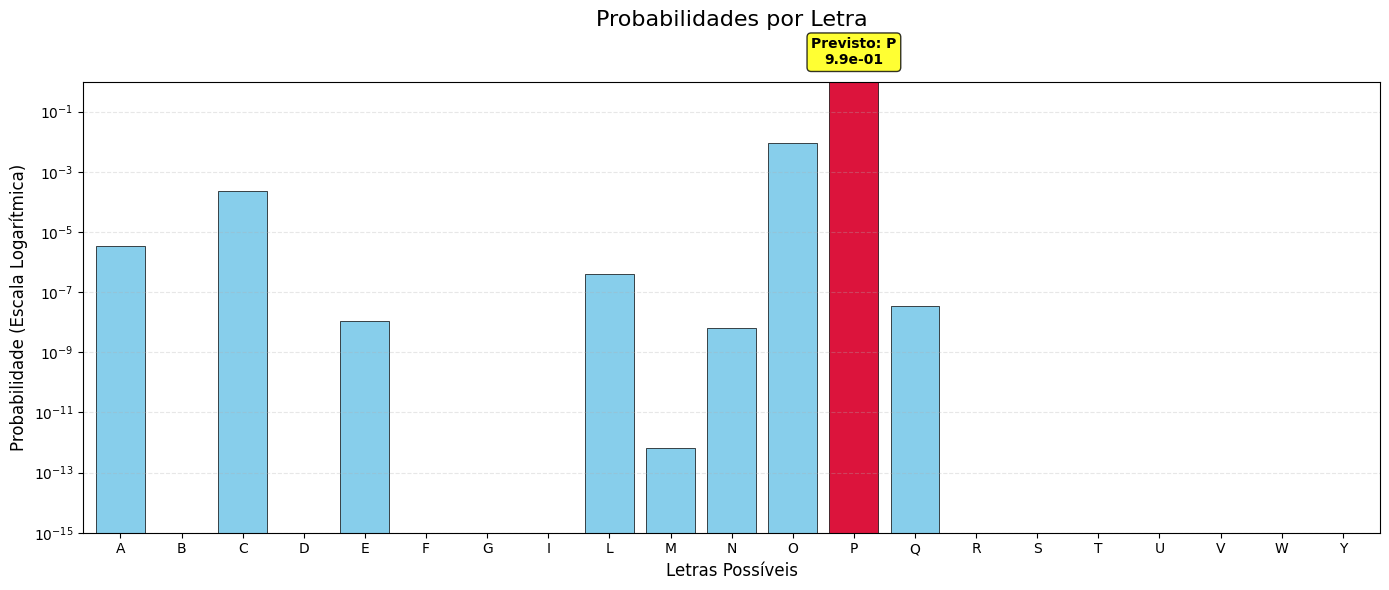

=== Acerto


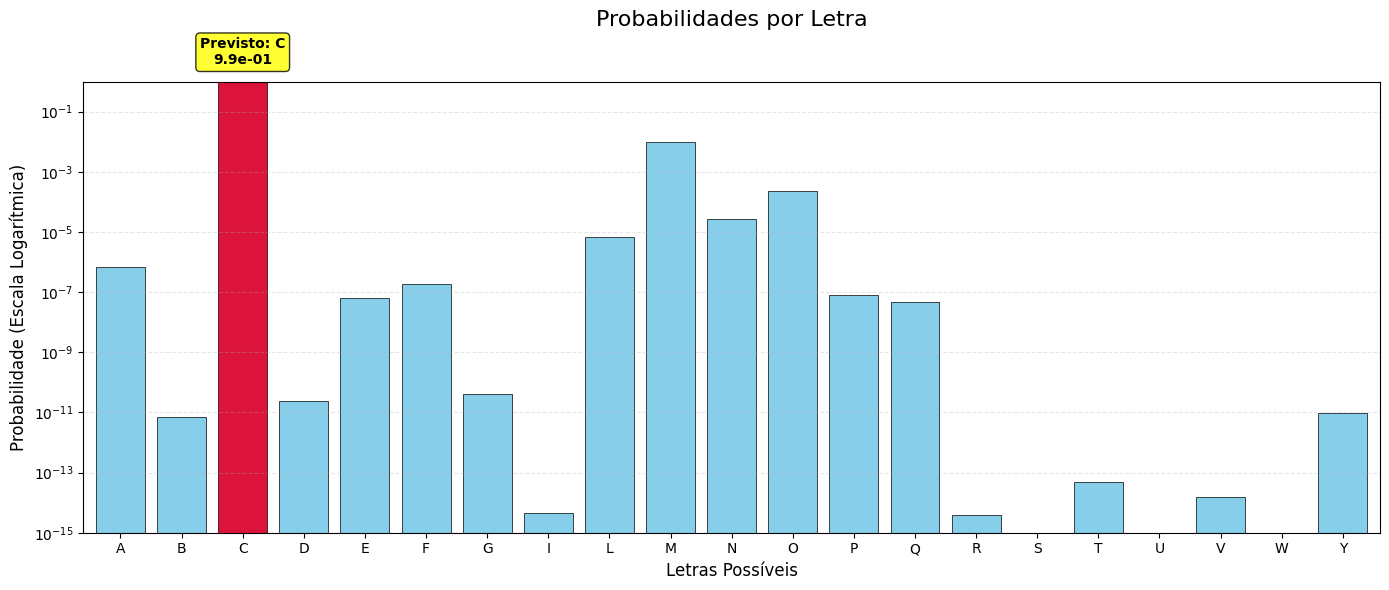

Erro


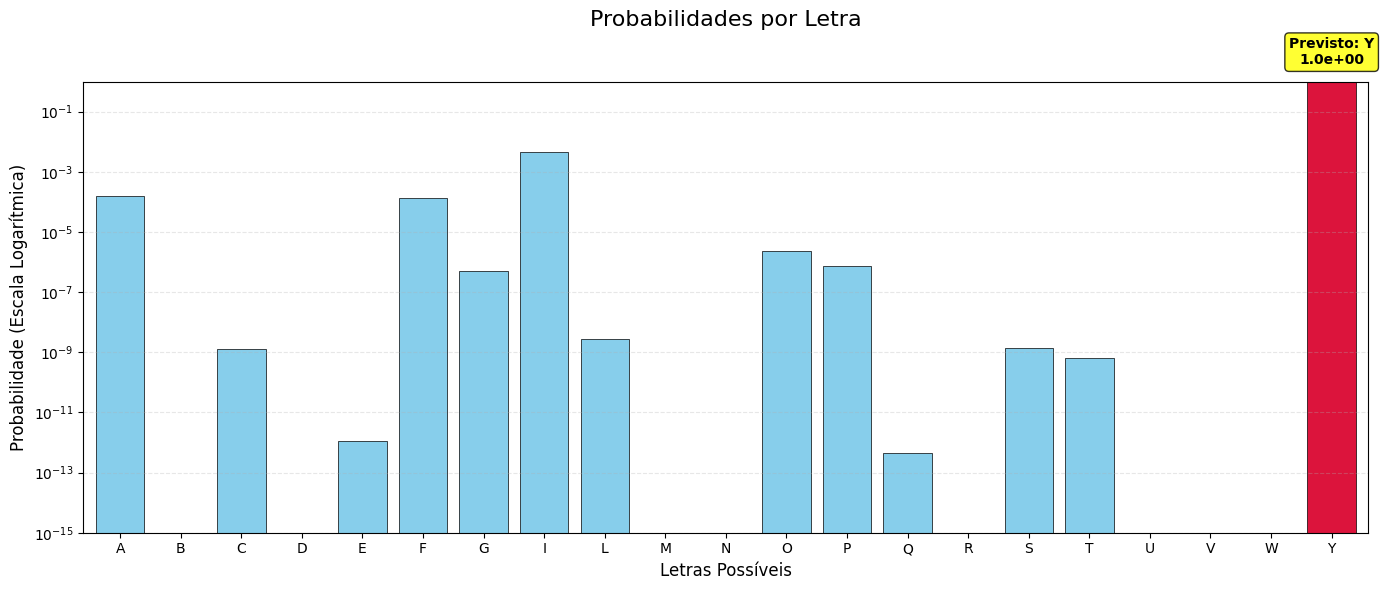

=== Acerto


In [13]:
def plote_bar_predictions(predictions_: list[float]) -> None:
    """
    @brief Plotará as predições em gráfico de barras de forma estilizada
    @param predictions Lista de predições gerada pela rede
    """

    # Criar figura com tamanho adequado
    fig, ax = plt.subplots(figsize=(14, 6))
    
    cores = ['skyblue'] * len(predictions_)
    indice_max = np.argmax(predictions_)
    cores[indice_max] = 'crimson'
    
    # Plotar barras
    barras = ax.bar(
        train_ds.class_names, 
        predictions_, # Colocamos o resultado direto  rede
        color=cores, 
        edgecolor='black', 
        linewidth=0.5
    )
    
    # Configuramos escala logarítmica e outros parâmetros
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-15, top=1)  # Ajustar limites
    ax.set_title('Probabilidades por Letra', fontsize=16, pad=40)
    ax.set_xlabel('Letras Possíveis', fontsize=12)
    ax.set_ylabel('Probabilidade (Escala Logarítmica)', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--', which='both')
    ax.margins(x=0.01)
    
    # Adicionamos uma anotação no gráfico
    ax.text(
        # Posição
        indice_max, predictions_[indice_max] * 3, 
        # Texto
        f'Previsto: {train_ds.class_names[indice_max]}\n{predictions_[indice_max]:.1e}', 
        # Forma da Caixa
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8),
    )
    
    plt.tight_layout()
    plt.show()

for letter in path_imgs:
    plote_bar_predictions(
        results[letter]["2"][1]
    )
    print('=' * 100)
    print(
        "=== Acerto" if results[letter]["2"][0][0] == letter else "Erro"
    )
    print('=' * 100)

#### Atente-se ao fato de que é uma escala logarítmica.

# Providências Para Uso em Microcontroladores

## Conversão para TensorFlow Lite (TFLite)
  
#### O TFLite é um formato otimizado que remove metadados desnecessários para o treinamento e foca apenas na execução (inferência).

## Quantização (Redução de bits)

#### Reduzir a precisão de float32 para int8 ou float16 é uma técnica inteligente para microcontroladores de baixa memória. Entretanto, a eficiência da rede em prever corretamente deve diminuir consideravelmente.